In [66]:

import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt


import cv2

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2

# **Understanding the data**

In [45]:
zip_path = "Insect Classification-20260428T080748Z-3-001.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [85]:
# Main dataset path
dataset_path = "/content/dataset/Insect Classification"

# Train and test paths
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

classes = os.listdir(train_path)

print("CLASSES:")
print(classes)
print("\nTotal Classes:", len(classes))


# -----------------------------
# COUNT TOTAL IMAGES
# -----------------------------

train_total = 0
test_total = 0

print("\nTRAIN IMAGE COUNT")
print("-------------------")

for cls in classes:

    class_path = os.path.join(train_path, cls)

    count = len(os.listdir(class_path))

    train_total += count

    print(f"{cls}: {count}")


print("\nTEST IMAGE COUNT")
print("-------------------")

for cls in classes:

    class_path = os.path.join(test_path, cls)

    count = len(os.listdir(class_path))

    test_total += count

    print(f"{cls}: {count}")


total_images = train_total + test_total

print("\nTOTAL TRAIN IMAGES:", train_total)
print("TOTAL TEST IMAGES :", test_total)
print("TOTAL IMAGES      :", total_images)


# -----------------------------
# FIND BAD / CORRUPTED IMAGES
# -----------------------------

bad_images = []

for folder in [train_path, test_path]:

    for cls in classes:

        class_path = os.path.join(folder, cls)

        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                bad_images.append(img_path)

print("\nBAD IMAGES FOUND:", len(bad_images))


CLASSES:
['stem_borer', 'sawfly', 'grasshopper', 'armyworm', 'aphids', 'mites', 'bollworm', 'beetle', 'mosquito']

Total Classes: 9

TRAIN IMAGE COUNT
-------------------
stem_borer: 168
sawfly: 186
grasshopper: 264
armyworm: 210
aphids: 254
mites: 240
bollworm: 231
beetle: 277
mosquito: 281

TEST IMAGE COUNT
-------------------
stem_borer: 36
sawfly: 37
grasshopper: 46
armyworm: 43
aphids: 44
mites: 42
bollworm: 36
beetle: 50
mosquito: 50

TOTAL TRAIN IMAGES: 2111
TOTAL TEST IMAGES : 384
TOTAL IMAGES      : 2495

BAD IMAGES FOUND: 0


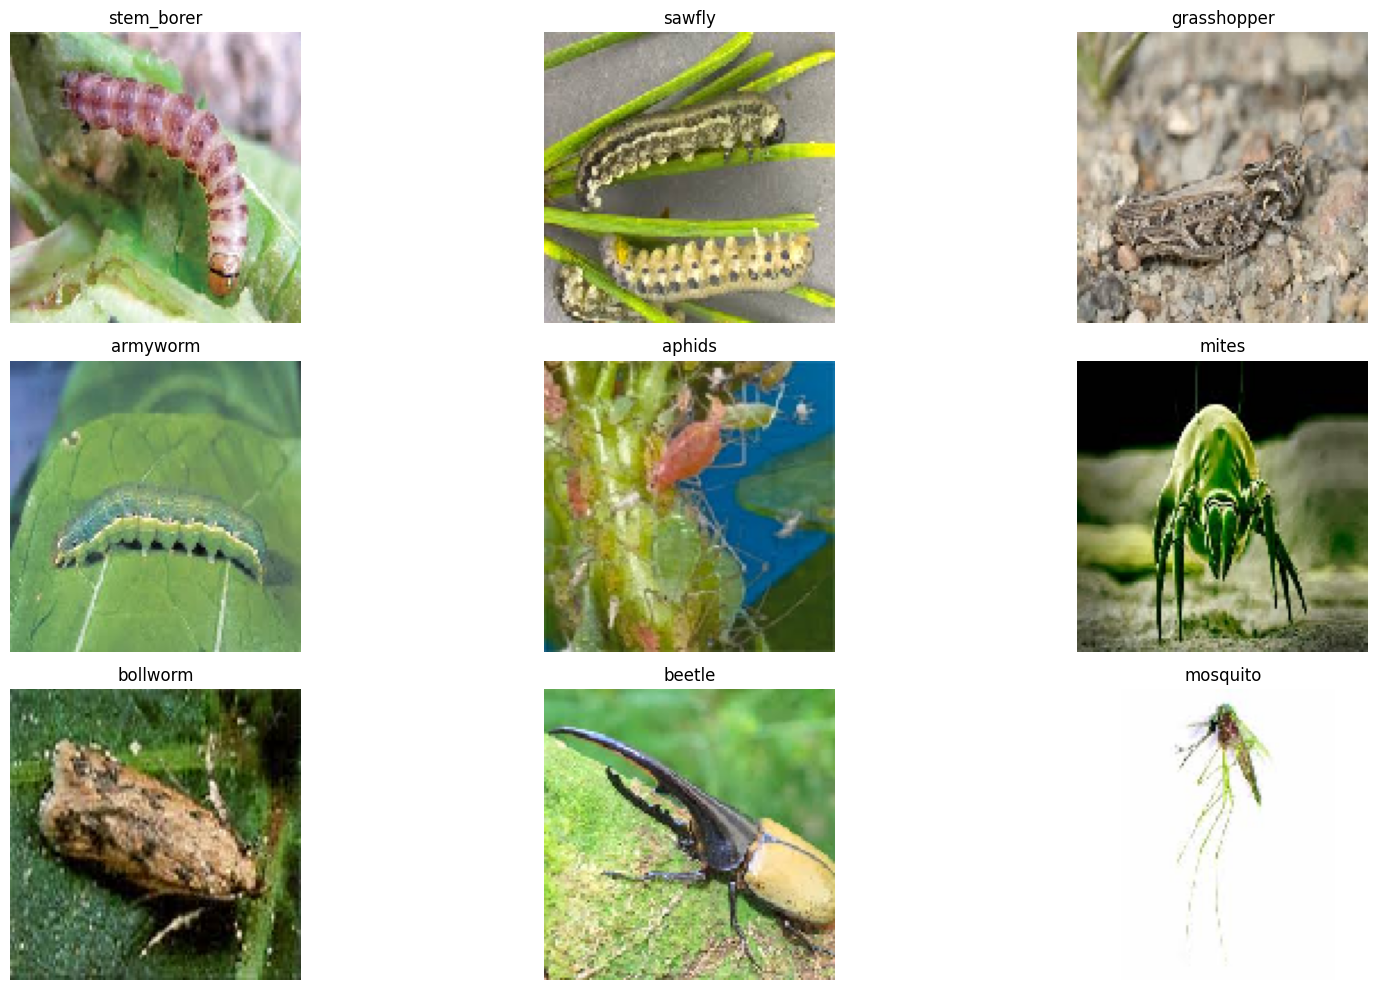

In [84]:
plt.figure(figsize=(18,10))

for i, cls in enumerate(classes):

    class_path = os.path.join(train_path, cls)

    img_files = os.listdir(class_path)

    img_loaded = False

    for img_name in img_files:

        img_path = os.path.join(class_path, img_name)

        try:
            img = load_img(img_path, target_size=(128,128))

            plt.subplot(3,3,i+1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")

            img_loaded = True
            break

        except:
            continue

plt.tight_layout()
plt.show()

In [48]:
dataset_path = "/content/dataset/Insect Classification"

removed = 0

for folder in ["train", "test"]:

    folder_path = os.path.join(dataset_path, folder)

    for cls in os.listdir(folder_path):

        class_path = os.path.join(folder_path, cls)

        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                os.remove(img_path)
                removed += 1

print("Removed bad images:", removed)

Removed bad images: 121


In [49]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/Insect Classification/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/Insect Classification/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2111 files belonging to 9 classes.
Found 384 files belonging to 9 classes.


# **Designing and Analyzing Convolutional Neural Networks from Scratch.**

In [50]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1)

])

Model Architecture:

In [36]:
model = Sequential([

    tf.keras.layers.Input(shape=(128,128,3)),

    # AUGMENTATION
    data_augmentation,

    # NORMALIZATION
    tf.keras.layers.Rescaling(1./255),

    # -------------------------
    # CONV BLOCK 1
    # -------------------------

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
    ),

    MaxPooling2D(pool_size=(2,2)),


    # -------------------------
    # CONV BLOCK 2
    # -------------------------

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),


    # -------------------------
    # CONV BLOCK 3
    # -------------------------

    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),


    # -------------------------
    # FLATTEN
    # -------------------------

    Flatten(),


    # -------------------------
    # FULLY CONNECTED LAYERS
    # -------------------------

    Dense(256, activation='relu'),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),


    # -------------------------
    # OUTPUT LAYER
    # -------------------------

    Dense(9, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,769 (25.02 MB)

 Trainable params: 6,557,769 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

Model Training:

In [39]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.2383 - loss: 2.0310 - val_accuracy: 0.3750 - val_loss: 1.7328
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.3704 - loss: 1.7102 - val_accuracy: 0.3620 - val_loss: 1.6109
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.4623 - loss: 1.4982 - val_accuracy: 0.4974 - val_loss: 1.4029
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5396 - loss: 1.2950 - val_accuracy: 0.6198 - val_loss: 1.1497
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6333 - loss: 1.0298 - val_accuracy: 0.6875 - val_loss: 0.8786
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6660 - loss: 0.9296 - val_accuracy: 0.7318 - val_loss: 0.8409
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7693 - loss: 0.6930 - val_accuracy: 0.7812 - val_loss: 0.8182
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8328 - loss: 0.4921 - val_accuracy: 0.8177 - v

Model Evaluation:

In [41]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9193 - loss: 0.3885
Test Loss: 0.38848331570625305
Test Accuracy: 0.9192708134651184


In [42]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(
    y_true,
    y_pred,
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        44
           1       0.79      0.86      0.82        43
           2       0.89      0.98      0.93        50
           3       1.00      0.97      0.99        36
           4       0.96      0.98      0.97        46
           5       0.90      0.90      0.90        42
           6       0.96      0.96      0.96        50
           7       0.89      0.84      0.86        37
           8       0.97      0.78      0.86        36

 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


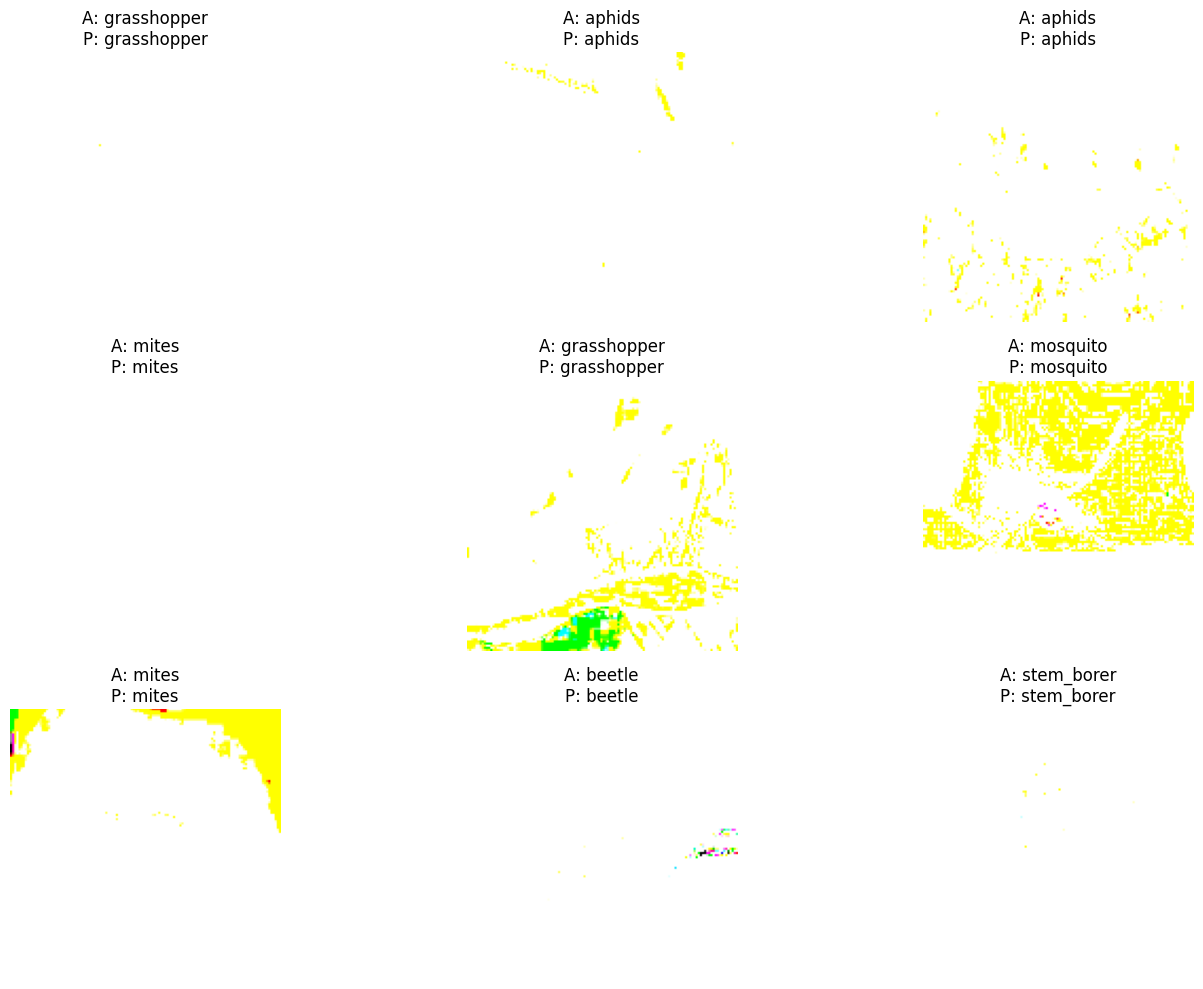

In [51]:
class_names = train_dataset.class_names

plt.figure(figsize=(15,10))

for images, labels in test_dataset.take(1):

    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy())

        actual = class_names[labels[i].numpy()]
        predicted = class_names[predicted_labels[i]]

        plt.title(f"A: {actual}\nP: {predicted}")

        plt.axis("off")

plt.tight_layout()
plt.show()

# **Deeper Architecture with Regularization Layer.**

Model Architecture:

In [78]:
deep_model = tf.keras.Sequential([


    tf.keras.layers.Input(shape=(128,128,3)),
    # -------------------------
    # AUGMENTATION
    # -------------------------
    data_augmentation,

    # -------------------------
    # NORMALIZATION
    # -------------------------
    tf.keras.layers.Rescaling(1./255),

    # -------------------------
    # CONV BLOCK 1
    # -------------------------
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    # -------------------------
    # CONV BLOCK 2
    # -------------------------
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    # -------------------------
    # CONV BLOCK 3
    # -------------------------
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    # -------------------------
    # CLASSIFIER
    # -------------------------
    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(9, activation='softmax')
])
deep_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_11 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,231,017 (65.73 MB)

 Trainable params: 17,230,569 (65.73 MB)

 Non-trainable params: 448 (1.75 KB)

Model Training:

In [79]:
deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [80]:
history_deep = deep_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.1326 - loss: 5.7455 - val_accuracy: 0.1380 - val_loss: 2.1876
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.1383 - loss: 2.2904 - val_accuracy: 0.1146 - val_loss: 2.1969
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.1459 - loss: 2.2235 - val_accuracy: 0.1224 - val_loss: 2.1936
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.1535 - loss: 2.1863 - val_accuracy: 0.1406 - val_loss: 2.1909
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.1625 - loss: 2.1661 - val_accuracy: 0.1667 - val_loss: 2.1564
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.1715 - loss: 2.1582 - val_accuracy: 0.2344 - val_loss: 2.1201
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.1909 - loss: 2.1374 - val_accuracy: 0.2396 - val_loss: 2.0521
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.1994 - loss: 2.0976 - val_accuracy: 0.2005

Model Evaluation:

In [81]:
test_loss, test_accuracy = deep_model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2891 - loss: 1.8902
Test Accuracy: 0.2890625
Test Loss: 1.8901804685592651


In [82]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = deep_model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(
    y_true,
    y_pred,
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
              precision    recall  f1-score   support

           0       0.16      0.95      0.27        44
           1       0.00      0.00      0.00        43
           2       0.60      0.54      0.57        50
           3       0.00      0.00      0.00        36
           4       0.62      0.17      0.27        46
           5       0.17      0.02      0.04        42
           6       0.62      0.66      0.64        50
           7       0.00      0.00      0.00        37
           8       0.00      0.00      0.00        36

 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Experimentation and Comparative Analysis:**

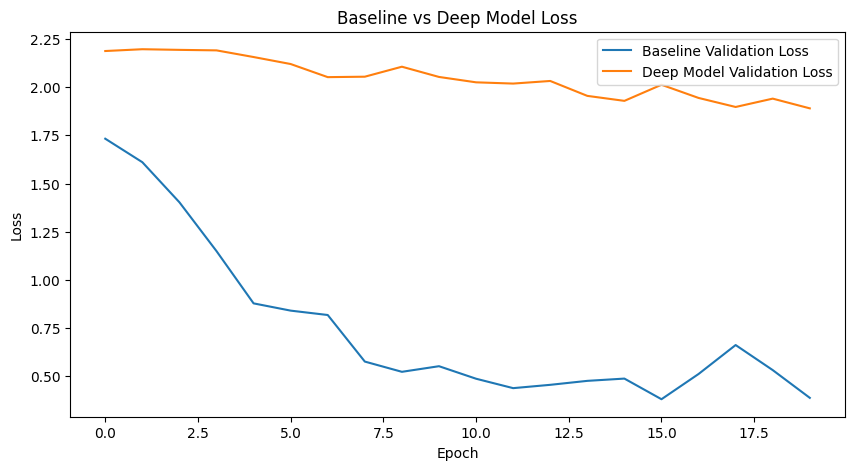

In [83]:
plt.figure(figsize=(10,5))

# Baseline
plt.plot(
    history.history['val_loss'],
    label='Baseline Validation Loss'
)

# Deep Model
plt.plot(
    history_deep.history['val_loss'],
    label='Deep Model Validation Loss'
)

plt.title("Baseline vs Deep Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [37]:
sgd_model = tf.keras.models.clone_model(model)

sgd_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.1042 - loss: 2.1975 - val_accuracy: 0.1172 - val_loss: 2.1946
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.1331 - loss: 2.1917 - val_accuracy: 0.1250 - val_loss: 2.1911
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.1563 - loss: 2.1868 - val_accuracy: 0.1484 - val_loss: 2.1875
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1544 - loss: 2.1828 - val_accuracy: 0.1693 - val_loss: 2.1840
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.1644 - loss: 2.1789 - val_accuracy: 0.1823 - val_loss: 2.1802
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.1767 - loss: 2.1751 - val_accuracy: 0.1953 - val_loss: 2.1768
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.1819 - loss: 2.1714 - val_accuracy: 0.1979 - val_loss: 2.1733
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.1914 - loss: 2.1681 - val_accuracy: 0.1979 - v

In [86]:
# Evaluate SGD model
test_loss, test_accuracy = sgd_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Store true labels and predictions
y_true = []
y_pred = []

# Predict on test dataset
for images, labels in test_dataset:

    predictions = sgd_model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.2448 - loss: 2.0899
Test Loss: 2.089855670928955
Test Accuracy: 0.2447916716337204
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
              precision    recall  f1-score   support

           0       0.35      0.27      0.31        44
           1       0.00      0.00      0.00        43
           2       0.43      0.64      0.51        50
           3       0.30      0.08      0.13        36
           4       0.06      0.07      0.06        46
           5       0.00      0.00      0.00        42
           6       0.21   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


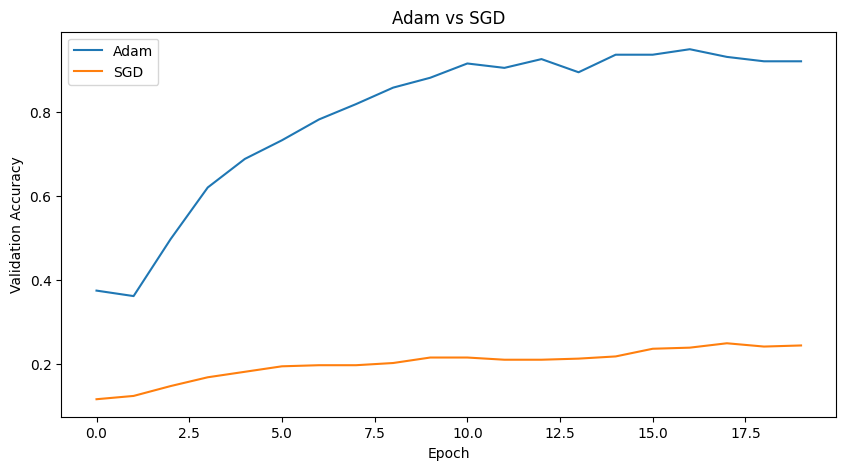

In [43]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['val_accuracy'],
    label='Adam'
)

plt.plot(
    history_sgd.history['val_accuracy'],
    label='SGD'
)

plt.title("Adam vs SGD")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()

plt.show()

# **Fine-Tuning a Pre-Trained Model (Transfer Learning).**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

In [ ]:
IMG_SIZE = (224, 224)

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
base_model.trainable = False

In [ ]:
transfer_model = models.Sequential([

    base_model,

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),

    layers.Dense(9, activation='softmax')
])
transfer_model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,171,529 (80.76 MB)

 Trainable params: 6,456,841 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/Insect Classification/train",
    image_size=(224,224),
    batch_size=32
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/Insect Classification/test",
    image_size=(224,224),
    batch_size=32
)

Found 2111 files belonging to 9 classes.
Found 384 files belonging to 9 classes.


In [ ]:
normalization = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x,y: (normalization(x), y))
test_dataset = test_dataset.map(lambda x,y: (normalization(x), y))

In [ ]:
history_tl = transfer_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 285ms/step - accuracy: 0.3676 - loss: 1.8469 - val_accuracy: 0.7630 - val_loss: 0.8848
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 250ms/step - accuracy: 0.6784 - loss: 0.9364 - val_accuracy: 0.9062 - val_loss: 0.4493
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 234ms/step - accuracy: 0.8157 - loss: 0.5189 - val_accuracy: 0.9479 - val_loss: 0.2213
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 223ms/step - accuracy: 0.8849 - loss: 0.3445 - val_accuracy: 0.9609 - val_loss: 0.1493
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 221ms/step - accuracy: 0.8958 - loss: 0.2821 - val_accuracy: 0.9688 - val_loss: 0.1410
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 228ms/step - accuracy: 0.9266 - loss: 0.2168 - val_accuracy: 0.9688 - val_loss: 0.1472
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 240ms/step - accuracy: 0.9266 - loss: 0.1915 - val_accuracy: 0.9661 - val_loss: 0.1424
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 234ms/step - accuracy: 0.9417 - loss: 0.1603 - val_accu

In [ ]:
loss, acc = transfer_model.evaluate(test_dataset)

print("Test Accuracy:", acc)
print("Test Loss:", loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.9714 - loss: 0.1974
Test Accuracy: 0.9713541865348816
Test Loss: 0.19740717113018036


In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = transfer_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      0.93      0.96        43
           2       1.00      1.00      1.00        50
           3       0.84      1.00      0.91        36
           4       1.00      0.98      0.99        46
           5       0.95      1.00      0.98        42
           6       1.00      0.98      0.99        50
           7       1.00      0.89      0.94        37
           8       0.94      0.94      0.94  